In [98]:
import ctopo
import numpy as np
import pandas as pd
from tqdm import tqdm 
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem

from rdkit import RDLogger  
RDLogger.DisableLog('rdApp.*')

In [99]:
# read ligands
df = pd.read_csv('../data/Gd/final/merged_reviews_mapped.csv')
Ls = [ctopo.Ligand(smi) for smi in df['smiles_mapped']]
target = df['lgK']

# dict of reprs
reprs = {
    'ligand': lambda x: x._mol,
    'topo': lambda x: x.get_topology(True, False),
    'topo_da': lambda x: x.get_topology(True, True),
    'skl': lambda x: x.get_skeleton(True, False, False, False),
    'skl_da': lambda x: x.get_skeleton(True, True, False, False),
    'skl_da_skl': lambda x: x.get_skeleton(True, True, True, False),
    'skl_da_bonds': lambda x: x.get_skeleton(True, True, False, True),
    'skl_da_skl_bonds': lambda x: x.get_skeleton(True, True, True, True),
    'cmplx': lambda x: x.get_complexophore(True, False, False, False, False, False),
    'cmplx_da': lambda x: x.get_complexophore(True, True, False, False, False, False),
    'cmplx_da_bonds': lambda x: x.get_complexophore(True, True, False, False, True, False),
    'cmplx_da_sub': lambda x: x.get_complexophore(True, True, False, True, False, False),
    'cmplx_da_sub_bonds': lambda x: x.get_complexophore(True, True, False, True, True, False),
    'cmplx_full': lambda x: x.get_complexophore(True, True, True, True, True, True),
}

In [100]:
def compute_morgan_fingerprint(mol, radius=2, nBits=2048):
    if mol is not None:
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits))
    else:
        return [None] * nBits

In [101]:
name = 'topo'
func = reprs[name]

fingerprints = []
for L in tqdm(Ls, desc=f"Building fps: {name}"):
    mol = func(L)
    fingerprints.append(compute_morgan_fingerprint(mol))
fp_df = pd.DataFrame(fingerprints, columns=[f'bit_{i}' for i in range(2048)])
fp_df['lgK'] = target

Building fps: topo: 100%|██████████| 217/217 [00:00<00:00, 1938.44it/s]


In [102]:
bit_cols = [c for c in fp_df.columns if c != 'lgK']
dupes = fp_df[fp_df.duplicated(subset=bit_cols, keep=False)].copy()
len(dupes)

194

In [103]:
lgk_dupl = []
for _, g in dupes.groupby(bit_cols, dropna=False):
    lgk_dupl.append(g['lgK'].tolist())

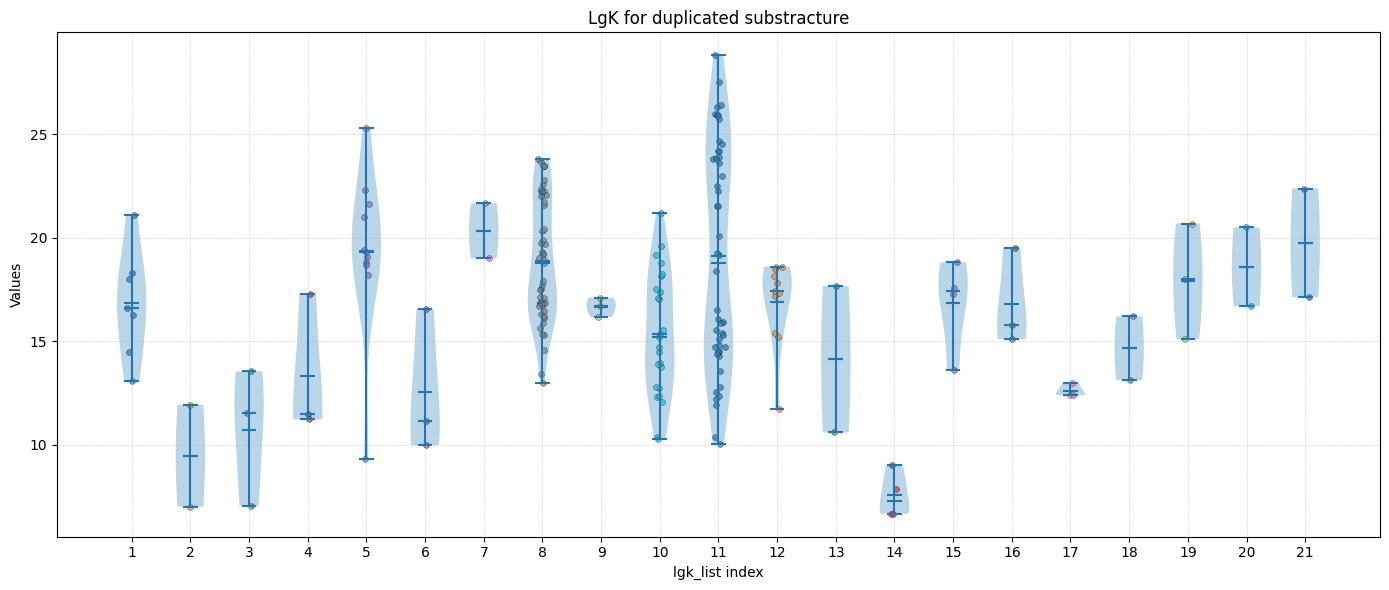

In [104]:
fig, ax = plt.subplots(figsize=(14, 6))

# Violin plot
ax.violinplot(
    lgk_dupl,
    positions=range(1, len(lgk_dupl) + 1),
    showmeans=True,
    showmedians=True,
    showextrema=True,
)

# Overlay raw data points with horizontal jitter
rng = np.random.default_rng(42)  # for reproducibility
for i, vals in enumerate(lgk_dupl, start=1):
    x = rng.normal(loc=i, scale=0.04, size=len(vals))  # jitter around the group index
    ax.scatter(x, vals, s=18, alpha=0.7, edgecolors="k", linewidths=0.3)

ax.set_title("LgK for duplicated substracture")
ax.set_xlabel("lgk_list index")
ax.set_ylabel("Values")
ax.set_xticks(range(1, len(lgk_dupl) + 1))
ax.set_xticklabels([str(i) for i in range(1, len(lgk_dupl) + 1)])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [105]:
bit_cols = [c for c in fp_df.columns if c != 'lgK']
fp_df['lgK'] = fp_df.groupby(bit_cols)['lgK'].transform('median')
fp_df = fp_df.drop_duplicates(subset=bit_cols, keep='first').reset_index(drop=True)
fp_df

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_2039,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047,lgK
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,18.780
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,18.770
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28.400
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,17.440
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15.220
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,11.660
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,17.440
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12.400
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,16.700
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,19.300


In [106]:
name = 'cmplx'
func = reprs[name]

fingerprints = []
for L in tqdm(Ls, desc=f"Building fps: {name}"):
    mol = func(L)
    fingerprints.append(compute_morgan_fingerprint(mol))
fp_df = pd.DataFrame(fingerprints, columns=[f'bit_{i}' for i in range(2048)])
fp_df['lgK'] = target

Building fps: cmplx: 100%|██████████| 217/217 [00:00<00:00, 1286.38it/s]


In [107]:
bit_cols = [c for c in fp_df.columns if c != 'lgK']
dupes = fp_df[fp_df.duplicated(subset=bit_cols, keep=False)].copy()
len(dupes)

48

In [108]:
lgk_dupl = []
for _, g in dupes.groupby(bit_cols, dropna=False):
    lgk_dupl.append(g['lgK'].tolist())

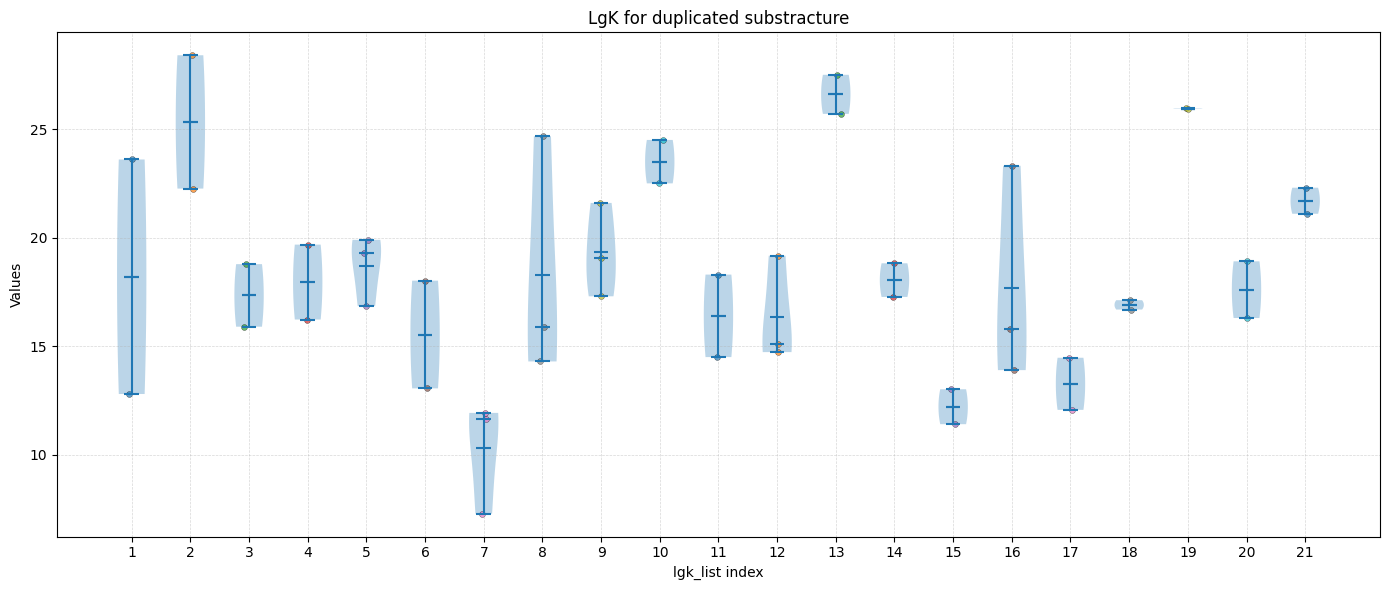

In [109]:
fig, ax = plt.subplots(figsize=(14, 6))

# Violin plot
ax.violinplot(
    lgk_dupl,
    positions=range(1, len(lgk_dupl) + 1),
    showmeans=True,
    showmedians=True,
    showextrema=True,
)

# Overlay raw data points with horizontal jitter
rng = np.random.default_rng(42)  # for reproducibility
for i, vals in enumerate(lgk_dupl, start=1):
    x = rng.normal(loc=i, scale=0.04, size=len(vals))  # jitter around the group index
    ax.scatter(x, vals, s=18, alpha=0.7, edgecolors="k", linewidths=0.3)

ax.set_title("LgK for duplicated substracture")
ax.set_xlabel("lgk_list index")
ax.set_ylabel("Values")
ax.set_xticks(range(1, len(lgk_dupl) + 1))
ax.set_xticklabels([str(i) for i in range(1, len(lgk_dupl) + 1)])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [110]:
bit_cols = [c for c in fp_df.columns if c != 'lgK']
fp_df['lgK'] = fp_df.groupby(bit_cols)['lgK'].transform('median')
fp_df = fp_df.drop_duplicates(subset=bit_cols, keep='first').reset_index(drop=True)
fp_df

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_2039,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047,lgK
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,19.30
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15.88
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25.33
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,23.90
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,18.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15.10
186,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,26.40
187,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,17.79
188,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,21.99


### SMILES vs fingerprint duplicates detection

In [38]:
bit_cols = [c for c in fp_df.columns if c != 'lgK']
df1 = fp_df.drop_duplicates(subset=bit_cols, keep='first').reset_index()
df1

,index,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,...,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047,smiles,lgK
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*]([2*])[2*]([2*])[2*],16.85
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*]([2*])[2*]([2*])[2*]1[2*],24.67
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*]([2*])[2*]([2*])[2*]([2*])[2*],28.40
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*][2*]([2*])[2*],18.60
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*]([2*])[2*],21.18
5,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*][2*][2*]([2*])[2*]1,11.66
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][1*]1[2*][2*][1*]([2*])[2*]([2*])[2*]([2*]...,17.44
7,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*][2*]([2*])[2*],12.40
8,18,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][1*]([2*])[2*]([2*])[2*]([2*])[2*]([2*])[1...,17.10
9,19,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*][2*]([2*])[2*]1[2*],21.00


In [39]:
bit_cols = [c for c in fp_df.columns if c not in ['smiles', 'lgK']]
df2 = fp_df.drop_duplicates(subset=bit_cols, keep='first').reset_index()
df2

,index,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,...,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047,smiles,lgK
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*]([2*])[2*]([2*])[2*],16.85
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*]([2*])[2*]([2*])[2*]1[2*],24.67
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*]([2*])[2*]([2*])[2*]([2*])[2*],28.40
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*][2*]([2*])[2*],18.60
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*]([2*])[2*],21.18
5,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*][2*][2*]([2*])[2*]1,11.66
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][1*]1[2*][2*][1*]([2*])[2*]([2*])[2*]([2*]...,17.44
7,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*][2*]([2*])[2*],12.40
8,18,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][1*]([2*])[2*]([2*])[2*]([2*])[2*]([2*])[1...,17.10
9,19,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*][2*]([2*])[2*]1[2*],21.00


In [40]:
dupes = df1[df1.duplicated(subset=bit_cols, keep=False)].copy()
df1 = dupes
df1

,index,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,...,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047,smiles,lgK
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*]([2*])[2*]([2*])[2*]1[2*],24.67
12,26,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*][2*]([2*])[2*]1,13.06
13,30,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*]([2*])[2*]1[2*],15.10
15,40,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][1*]1[1*]([2*])[2*]([2*])[2*]([2*])[2*]1[2*],15.39
20,52,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][1*]([2*])[2*]([2*]([2*])[2*])[2*]([2*])[2*],21.66
25,72,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*],11.54
28,87,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*]([2*]([2*])[2*])[2*]([2*])[2*],19.00
29,92,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*][2*]([2*])[2*][2*]([2*])[2*]1,16.27
44,178,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][2*]1[2*]([2*])[2*]([2*])[2*]([2*])[2*]1[2*],15.88
48,205,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[2*][1*]1[2*]([2*])[1*]([2*])[2*]([2*])[2*]1[2*],15.30


In [45]:
for keys, g in df1.groupby(bit_cols, dropna=False):
    key_repr = (
        dict(zip(bit_cols, keys))
        if isinstance(keys, tuple) else
        {bit_cols[0]: keys}
    )
    pairs = list(zip(g['smiles'].tolist(), g['lgK'].tolist()))
    print(f"{pairs}")

[('[2*][2*]1[2*][2*]([2*])[2*]1', 13.06), ('[2*][2*]1[2*][2*]([2*])[2*][2*]([2*])[2*]1', 16.27)]
[('[2*][2*]([2*])[2*]', 11.54), ('[2*][1*]([2*])[2*]', 7.04)]
[('[2*][1*]([2*])[2*]([2*]([2*])[2*])[2*]([2*])[2*]', 21.66), ('[2*][2*]([2*])[2*]([2*]([2*])[2*])[2*]([2*])[2*]', 19.0)]
[('[2*][2*]1[2*]([2*])[2*]([2*])[2*]1[2*]', 24.67), ('[2*][2*]1[2*]([2*])[2*]1[2*]', 15.1), ('[2*][1*]1[1*]([2*])[2*]([2*])[2*]([2*])[2*]1[2*]', 15.39), ('[2*][2*]1[2*]([2*])[2*]([2*])[2*]([2*])[2*]1[2*]', 15.88), ('[2*][1*]1[2*]([2*])[1*]([2*])[2*]([2*])[2*]1[2*]', 15.3)]


In [17]:
out = (
    df1
    .merge(df2.drop_duplicates(), how="left", indicator=True)
    .loc[lambda x: x["_merge"] == "left_only", df1.columns]
)

out

,index,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,...,bit_2039,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047,smiles
13,30,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[2*][2*]1[2*]([2*])[2*]1[2*]
15,40,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[2*][1*]1[1*]([2*])[2*]([2*])[2*]([2*])[2*]1[2*]
28,87,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[2*][2*]([2*])[2*]([2*]([2*])[2*])[2*]([2*])[2*]
29,92,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[2*][2*]1[2*][2*]([2*])[2*][2*]([2*])[2*]1
44,178,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[2*][2*]1[2*]([2*])[2*]([2*])[2*]([2*])[2*]1[2*]
48,205,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[2*][1*]1[2*]([2*])[1*]([2*])[2*]([2*])[2*]1[2*]
50,216,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[2*][1*]([2*])[2*]
